# Highway

In [4]:
%matplotlib inline
import gymnasium
import highway_env
import matplotlib.pyplot as plt
import os
import numpy as np
from config import SHARED_CORE_ENV_ID, SHARED_CORE_CONFIG
from IPython import display


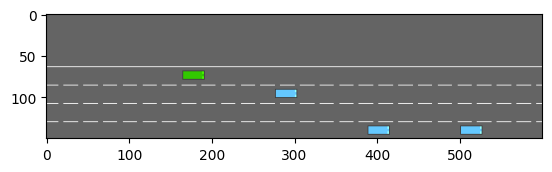

In [5]:
env = gymnasium.make(
  SHARED_CORE_ENV_ID,
  config=SHARED_CORE_CONFIG,
  render_mode='rgb_array',
)
env.reset()
plt.imshow(env.render())
plt.show()



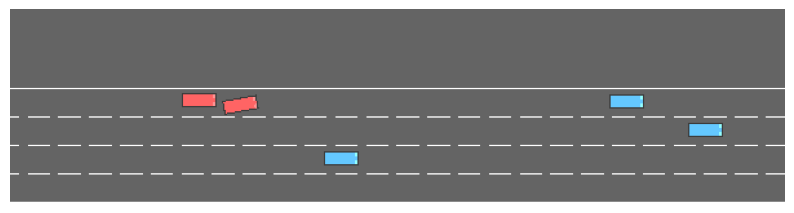

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
img = ax.imshow(env.render())
ax.axis('off')

for _ in range(200):
    action = env.action_space.sample()  # ou ton agent
    obs, reward, terminated, truncated, info = env.step(action)
    
    img.set_data(env.render())
    display.display(fig)
    display.clear_output(wait=True)
    
    if terminated or truncated:
        obs, _ = env.reset()

env.close()


### Manual DQN

In [ ]:
import torch
import torch.nn as nn
import random
import torch.optim as optim
from copy import deepcopy


Buffer

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state, action, reward, terminated, next_state):
        """Saves a transition."""
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, reward, terminated, next_state)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.choices(self.memory, k=batch_size)

    def __len__(self):
        return len(self.memory)


Network

In [5]:
class Net(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super(Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions)
        )

    def forward(self, x):
        return self.net(x)

### base form of the DQN agent

In [ ]:
class DQN_base_form:
    def __init__(self,
                 action_space,
                 observation_space,
                 gamma,
                 batch_size,
                 buffer_capacity,
                 update_target_every,
                 epsilon_start,
                 decrease_epsilon_factor,
                 epsilon_min,
                 learning_rate,
                 ):
        
        self.action_space = action_space
        self.observation_space = observation_space
        self.gamma = gamma
        
        self.batch_size = batch_size
        self.buffer_capacity = buffer_capacity
        self.update_target_every = update_target_every
        
        self.epsilon_start = epsilon_start
        self.decrease_epsilon_factor = decrease_epsilon_factor # larger -> more exploration
        self.epsilon_min = epsilon_min
        
        self.learning_rate = learning_rate
        
        self.reset()
    def reset(self):
        hidden_size = 128
        
        obs_size = self.observation_space.shape[0]
        n_actions = self.action_space.n
        
        self.buffer = ReplayBuffer(self.buffer_capacity)
        self.q_net =  Net(obs_size, hidden_size, n_actions)
        self.target_net = Net(obs_size, hidden_size, n_actions)
        
        self.loss_function = nn.MSELoss()
        self.optimizer = optim.Adam(params=self.q_net.parameters(), lr=self.learning_rate)
        
        self.epsilon = self.epsilon_start
        self.n_steps = 0
        self.n_eps = 0
    def get_action(self, state, epsilon=None):
            pass

    
    

### DQN 1st simple agent

In [ ]:
class DQN_agentI(DQN_base_form):
    def get_action(self, state, epsilon=None):
        """
            ** Solution ** 
        
            Return action according to an epsilon-greedy exploration policy
        """
        if epsilon is None: 
            epsilon = self.epsilon
            
        if np.random.rand() < epsilon: 
            return env.action_space.sample()
        else: 
            return np.argmax(self.get_q(state))
    def update(self, state, action, reward, terminated, next_state):

        # add data to replay buffer
        self.buffer.push(torch.tensor(state).unsqueeze(0), 
                           torch.tensor([[action]], dtype=torch.int64), 
                           torch.tensor([reward]), 
                           torch.tensor([terminated], dtype=torch.int64), 
                           torch.tensor(next_state).unsqueeze(0),
                          )

        if len(self.buffer) < self.batch_size:
            return np.inf

        # get batch
        transitions = self.buffer.sample(self.batch_size)

        state, action, reward, terminated, next_state = transitions
        val = self.q_net.forward(state)[action]
        target = (not terminated) * (reward + self.gamma * np.max(self.q_net.forward(next_state)))
        loss = self.loss(val, target)
        
        # Optimize the model 
        loss.backward()
        self.optimizer.step()
        

        return loss.detach().numpy()

### loops and utils

In [ ]:
def eval_agent(agent, env, n_sim=10):
    """    
    Monte Carlo evaluation of the agent.

    Repeat n_sim times:
        * Run the agent policy until the environment reaches a terminal state (= one episode)
        * Compute the sum of rewards in this episode
        * Store the sum of rewards in the episode_rewards array.
    """
    env_copy = deepcopy(env)
    episode_rewards = np.zeros(n_sim)
    for i in range(n_sim):
        state, _ = env_copy.reset()
        reward_sum = 0
        done = False
        while not done: 
            action = agent.get_action(state, epsilon=0)
            state, reward, terminated, truncated, _ = env_copy.step(action)
            reward_sum += reward
            done = terminated or truncated
        episode_rewards[i] = reward_sum
    return episode_rewards

In [ ]:
def train(env, agent, N_episodes, eval_every=10, reward_threshold=300):
    total_time = 0
    state, _ = env.reset()
    losses = []
    for ep in range(N_episodes):
        done = False
        state, _ = env.reset()
        while not done: 
            action = agent.get_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            loss_val = agent.update(state, action, reward, terminated, next_state)

            state = next_state
            losses.append(loss_val)

            done = terminated or truncated
            total_time += 1

        if ((ep+1)% eval_every == 0):
            rewards = eval_agent(agent, env)
            print("episode =", ep+1, ", reward = ", np.mean(rewards))
            if np.mean(rewards) >= reward_threshold:
                break
                
    return losses


Pipeline

### Stable Baseline

In [8]:
from stable_baselines3 import DQN

In [9]:
model = DQN('MlpPolicy', env,
              policy_kwargs=dict(net_arch=[256, 256]),
              learning_rate=5e-4,
              buffer_size=15000,
              learning_starts=200,
              batch_size=32,
              gamma=0.8,
              train_freq=1,
              gradient_steps=1,
              target_update_interval=50,
              verbose=1,
              tensorboard_log="highway_dqn/")
model.learn(int(2e4))
model.save("highway_dqn/model")

# Load and test saved model
model = DQN.load("highway_dqn/model")
while True:
  done = truncated = False
  obs, info = env.reset()
  while not (done or truncated):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    env.render()


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to highway_dqn/DQN_3
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10.2     |
|    ep_rew_mean      | 7.51     |
|    exploration_rate | 0.981    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3        |
|    time_elapsed     | 12       |
|    total_timesteps  | 41       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 9.38     |
|    ep_rew_mean      | 6.91     |
|    exploration_rate | 0.964    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2        |
|    time_elapsed     | 26       |
|    total_timesteps  | 75       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10.5     |
| 

KeyboardInterrupt: 